# 09 — Shape Difference Operators

**The question:** given a functional map $C$ between two shapes, how do we quantify *how much* they differ, and *where* the deformation is concentrated?

## Intuition

For a perfect isometry (e.g. two different poses of the same character), the functional map $C$ is exactly orthogonal: $C^\top C = I$.

When the shapes are *not* isometric, $C^\top C \neq I$. The deviation of $C^\top C$ from the identity encodes **how much** the map stretches or compresses functions — which is a measure of the geometric distortion.

This is the **shape difference operator** $S_D = C^\top C$. Its eigenvalues tell us the principal modes of distortion, and its eigenvectors (projected back onto the surface) reveal *where* on the surface the shapes differ most.

## Minimal math

**Area-based shape difference** (Rustamov et al., 2011):

$$S_D = C^\top C \in \mathbb{R}^{K_A \times K_A}$$

$S_D$ is symmetric positive semi-definite. Its eigendecomposition $S_D = U \Sigma U^\top$ gives eigenvalues $\mu_1, \ldots, \mu_{K_A} \geq 0$:
- $\mu_k = 1$ for all $k$: the map preserves all "areas" (isometry)
- $\mu_k > 1$: the map locally expands functions (area expansion)
- $\mu_k < 1$: the map locally compresses functions (area contraction)

**Per-vertex distortion** maps the spectral distortion back to the surface. The distortion at vertex $v$ is:

$$d(v) = \sum_{k=1}^{K_A} (\mu_k - 1)^2 \, \phi_k^A(v)^2$$

This gives a scalar field on $A$ showing which regions are most deformed.

**Conformal shape difference** (measures angle distortion separately from area):

$$S_C = \Lambda_A^{-1/2}\, C^\top \Lambda_B\, C\, \Lambda_A^{-1/2}$$

where $\Lambda_A = \mathrm{diag}(\lambda_1^A, \ldots, \lambda_{K_A}^A)$ (excluding the zero eigenvalue). For a conformal map, $S_C = I$.

In [7]:
import sys
from pathlib import Path

import gsops.backend as gs
import matplotlib.pyplot as plt
import numpy as np

import geomfum
from geomfum.dataset import NotebooksDataset
from geomfum.descriptor.pipeline import (
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import WaveKernelSignature
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    OperatorCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize
from geomfum.shape import TriangleMesh

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import setup_pyvista, show_mesh  # noqa: E402

setup_pyvista()

## Setup: compute functional map $C$

In [8]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(dataset.get_filename("cat-00"))
mesh_b = TriangleMesh.from_file(dataset.get_filename("lion-00"))

K = 128
mesh_a.laplacian.find_spectrum(spectrum_size=K, set_as_basis=True)
mesh_b.laplacian.find_spectrum(spectrum_size=K, set_as_basis=True)

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\cat-00.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\lion-00.off').


(array([-4.34530883e-14,  1.08692580e+01,  1.81320950e+01,  2.90812660e+01,
         3.06173749e+01,  3.12651252e+01,  4.78481503e+01,  8.78504820e+01,
         1.40470146e+02,  1.47856194e+02,  1.49164759e+02,  1.72857180e+02,
         1.76642726e+02,  2.07807791e+02,  2.44858198e+02,  2.76816825e+02,
         3.00135675e+02,  3.01929992e+02,  3.31792544e+02,  3.76725198e+02,
         3.80675117e+02,  4.39189453e+02,  4.40434106e+02,  4.67869854e+02,
         5.01610789e+02,  5.41754796e+02,  5.51533782e+02,  5.68138789e+02,
         5.73241345e+02,  6.27962720e+02,  6.50075188e+02,  6.70621587e+02,
         6.82782441e+02,  7.11999556e+02,  7.42171097e+02,  7.76985084e+02,
         7.88552673e+02,  8.20376895e+02,  8.40174148e+02,  8.82438945e+02,
         9.01253188e+02,  9.05191559e+02,  9.40694542e+02,  9.67937725e+02,
         1.01222528e+03,  1.02144583e+03,  1.02531778e+03,  1.08542925e+03,
         1.11444708e+03,  1.15586949e+03,  1.16441456e+03,  1.18036588e+03,
         1.1

C computed: (30, 30)


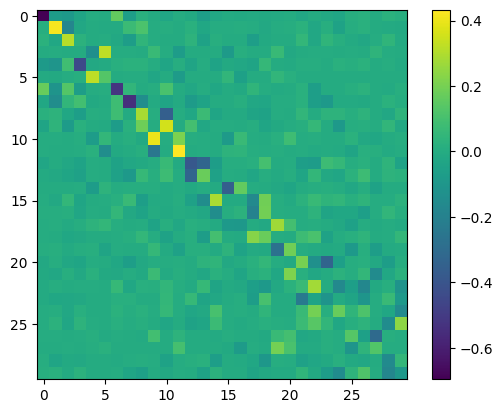

In [9]:
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature

mesh_a.landmark_indices = gs.array([2840, 1594, 5596, 6809, 3924, 7169])
mesh_b.landmark_indices = gs.array([1334, 834, 4136, 4582, 3666, 4955])

pipeline = DescriptorPipeline(
    [
        WaveKernelSignature(n_domain=64, k=128),
        LandmarkWaveKernelSignature(n_domain=64, k=128),
        L2InnerNormalizer(),
    ]
)
descr_a = pipeline.apply(mesh_a)
descr_b = pipeline.apply(mesh_b)

mesh_a.basis.use_k = 30
mesh_b.basis.use_k = 30
objective = FactorSum(
    [
        SpectralDescriptorPreservation(
            mesh_a.basis.project(descr_a),
            mesh_b.basis.project(descr_b),
            weight=1.0,
        ),
        LBCommutativityEnforcing.from_bases(mesh_a.basis, mesh_b.basis, weight=1e-2),
        OperatorCommutativityEnforcing.from_multiplication(
            mesh_a.basis, descr_a, mesh_b.basis, descr_b, weight=1e-1
        ),
    ]
)

x0 = gs.zeros((mesh_a.basis.use_k, mesh_b.basis.use_k))
res = ScipyMinimize(method="L-BFGS-B").minimize(
    objective, x0, fun_jac=objective.gradient
)
C = (res.x).reshape(mesh_a.basis.use_k, mesh_b.basis.use_k)
print(f"C computed: {C.shape}")
plt.imshow(C)
plt.colorbar()
plt.show()

## Area-based shape difference $S_D = C^\top C$

In [10]:
S_D = C.T @ C  # (30, 30), symmetric PSD

# Sanity check: for a perfect isometry S_D = I
orth_error = np.linalg.norm(S_D - np.eye(30), "fro")
print(f"||S_D - I||_F = {orth_error:.4f}  (0 = isometry)")

||S_D - I||_F = 4.5516  (0 = isometry)


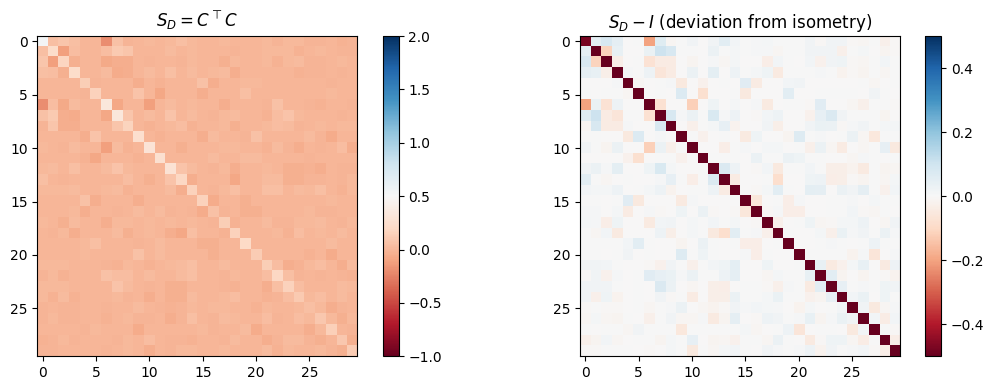

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(S_D, cmap="RdBu", vmin=-1, vmax=2)
axes[0].set_title("$S_D = C^\\top C$")
plt.colorbar(im, ax=axes[0])

im2 = axes[1].imshow(S_D - np.eye(30), cmap="RdBu", vmin=-0.5, vmax=0.5)
axes[1].set_title("$S_D - I$ (deviation from isometry)")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Eigenvalues of $S_D$

The eigenvalues $\mu_k$ of $S_D$ are the squared singular values of $C$. For an isometry all $\mu_k = 1$. Deviation from 1 indicates distortion.

In [12]:
mu, U = np.linalg.eigh(S_D)  # eigenvalues sorted ascending
mu = mu[::-1]  # sort descending
U = U[:, ::-1]

print(f"Min eigenvalue: {mu.min():.4f}")
print(f"Max eigenvalue: {mu.max():.4f}")
print(f"Eigenvalues near 1 (ideal): {np.sum(np.abs(mu - 1) < 0.1)} out of {K}")

Min eigenvalue: 0.0000
Max eigenvalue: 0.7207
Eigenvalues near 1 (ideal): 0 out of 128


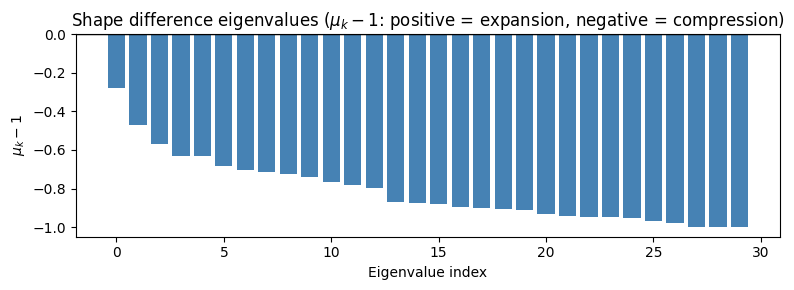

In [13]:
plt.figure(figsize=(8, 3))
plt.bar(
    np.arange(30), mu - 1, color=["crimson" if v > 0 else "steelblue" for v in mu - 1]
)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Eigenvalue index")
plt.ylabel("$\\mu_k - 1$")
plt.title(
    "Shape difference eigenvalues ($\\mu_k - 1$: positive = expansion, negative = compression)"
)
plt.tight_layout()
plt.show()

## Per-vertex distortion map

We project the eigenvalue distortion back onto the surface of shape $A$:

$$d(v) = \sum_{k} (\mu_k - 1)^2 \, [U^\top \Phi_A^\top](k, v)^2$$

More precisely, the distortion modes in the eigenbasis of $S_D$ become functions on $A$ via $\Phi_A U$.

In [14]:
Phi_A = mesh_a.basis.vecs  # (n_a, K)

# Distortion modes on A: (n_a, K)
# The k-th distortion mode is: Phi_A @ U[:, k]
distortion_modes = Phi_A @ U  # (n_a, K)

# Per-vertex distortion: weighted sum of squared mode values
weights = (mu - 1) ** 2  # (K,)
d_vertex = (distortion_modes**2 * weights[None, :]).sum(axis=1)  # (n_a,)

print(f"Distortion range: [{d_vertex.min():.4f},  {d_vertex.max():.4f}]")

Distortion range: [22.7267,  196.7536]


Per-vertex distortion on cat (bright = more deformed relative to lion)


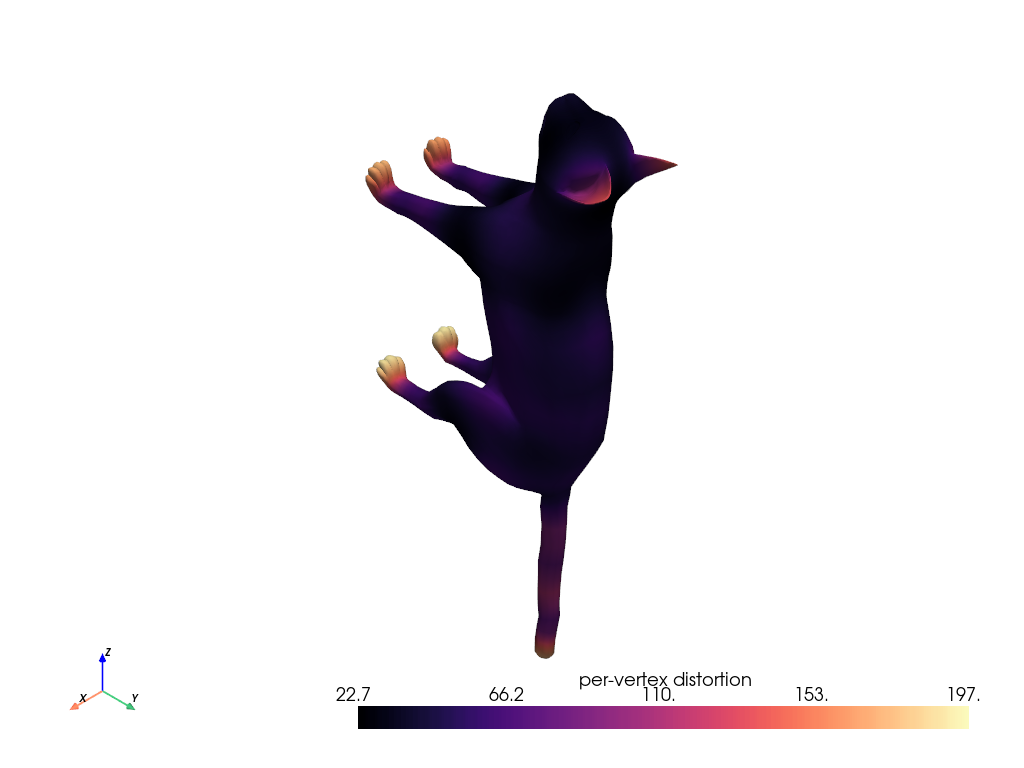

In [15]:
print("Per-vertex distortion on cat (bright = more deformed relative to lion)")
show_mesh(
    mesh_a.vertices,
    mesh_a.faces,
    scalars=d_vertex,
    scalar_name="per-vertex distortion",
    cmap="magma",
    smooth=True,
)

## Conformal shape difference $S_C$

$S_C$ separates angle distortion from area distortion. It equals $I$ for a conformal map, even if the map is not isometric.

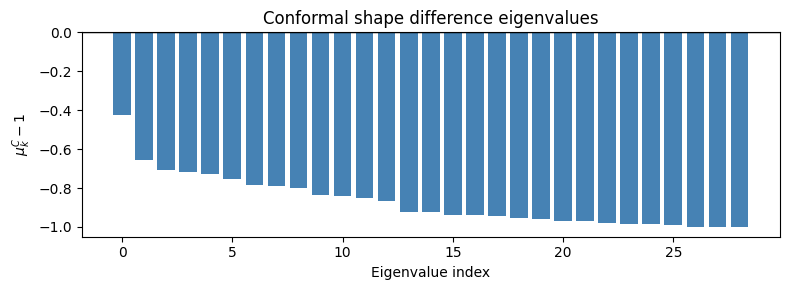

In [16]:
lam_a = mesh_a.basis.nonzero_vals  # skip lambda_0 = 0
lam_b = mesh_b.basis.nonzero_vals

K_nz = min(len(lam_a), len(lam_b), K - 1)  # number of nonzero eigenvalues to use

# Truncate C to the nonzero-eigenvalue rows/cols
C_nz = C[1 : K_nz + 1, 1 : K_nz + 1]  # skip first row/col (zero eigenvalue)
lam_a_nz = lam_a[:K_nz]
lam_b_nz = lam_b[:K_nz]

# S_C = Lambda_A^{-1/2} C^T Lambda_B C Lambda_A^{-1/2}
inv_sqrt_lam_a = np.diag(1.0 / np.sqrt(lam_a_nz))
Lambda_B = np.diag(lam_b_nz)

S_C = inv_sqrt_lam_a @ C_nz.T @ Lambda_B @ C_nz @ inv_sqrt_lam_a

mu_c, _ = np.linalg.eigh(S_C)
mu_c = mu_c[::-1]

plt.figure(figsize=(8, 3))
plt.bar(
    np.arange(len(mu_c)),
    mu_c - 1,
    color=["crimson" if v > 0 else "steelblue" for v in mu_c - 1],
)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Eigenvalue index")
plt.ylabel("$\\mu_k^C - 1$")
plt.title("Conformal shape difference eigenvalues")
plt.tight_layout()
plt.show()

## Interpretation

| Operator | $\mu_k = 1$ for | Encodes |
|---|---|---|
| $S_D = C^\top C$ | isometries | area distortion |
| $S_C = \Lambda_A^{-1/2} C^\top \Lambda_B C \Lambda_A^{-1/2}$ | conformal maps | angle/frequency distortion |

Comparing $S_D$ and $S_C$ allows disentangling area change from angle change, which is useful in medical shape analysis (e.g. brain cortex morphometry).

## Where to go next

This is the last notebook in the concepts series. You now have the full picture:

| Topic | Notebook |
|---|---|
| Geometric objects | [00](./00_geometric_objects.ipynb) |
| Functions on shapes | [01](./01_functions_on_shapes.ipynb) |
| Operators & Laplacian | [02](./02_operators_and_laplacian.ipynb) |
| Bases | [03](./03_what_is_a_basis.ipynb) |
| Tangent vectors & vector fields | [04](./04_tangent_vectors_and_operators.ipynb) |
| Spectral filtering | [05](./05_spectral_filtering.ipynb) |
| Correspondences | [06](./06_correspondences.ipynb) |
| Functional maps | [07](./07_functional_maps.ipynb) |
| Signal transfer | [08](./08_signal_transfer.ipynb) |
| Shape difference | [09](./09_shape_difference_operators.ipynb) |

Next steps: explore the `how_to/` notebooks for GeomFuM API details, or the `demos/` for complete end-to-end pipelines.